### Name : Mayur Kharat | PRN : 125B2B002

# Assignment 1: Data Cleaning, Exploratory Data Analysis (EDA) and PCA
## Backdrop-Conditioned Analogy Precedent Modeling (BCAPM)

* **Course**: Machine Learning Lab
* **Assignment**: Assignment 1 - Data Preprocessing, EDA, Feature Selection, and PCA
* **Dataset**: BCAPM Startup Dataset (Crunchbase, World Bank, Hacker News)
* **Total Samples**: 65,930 historical startups

---


## Assignment Objectives

This notebook performs the following data preprocessing and analysis steps:
1. **Dataset Selection**: Ingesting startup firmographics and macroeconomic indicators.
2. **Missing Values**: Filling missing values using sector medians and fallbacks.
3. **Outlier Treatment**: Identifying outliers with IQR and applying log scaling.
4. **Encoding Categoricals**: Converting text columns into numbers using One-Hot and Label Encoding.
5. **Plotting Distributions**: Visualizing continuous feature distributions and target class balance.
6. **Correlation Analysis**: Finding feature correlations using Pearson coefficient.
7. **Feature Selection**: Ranking feature importance using Variance Threshold, Pearson correlation, Mutual Information, and Random Forest.
8. **Principal Component Analysis (PCA)**: Standardizing features, plotting Scree plots, and reducing dimensions.

---


In [ ]:
import sys
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import VarianceThreshold, mutual_info_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA

# Display & Visual Settings
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 50)

# Resolve project paths
PROJECT_ROOT = Path('.').resolve().parent if Path('.').resolve().name == 'notebooks' else Path('.').resolve()
DATA_RAW_DIR = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project Root: {PROJECT_ROOT}")
print(f"Processed Data Path: {DATA_PROCESSED_DIR}")


Project Root: D:\PROJECTS\BCAPM\BCAMP
Processed Data Path: D:\PROJECTS\BCAPM\BCAMP\data\processed


## Step 1: Dataset Selection and Overview

### Dataset Context
The dataset comes from the BCAPM startup research project, combining:
1. **Crunchbase VC Investments**: Startup funding total, funding rounds, location, and market category.
2. **Y Combinator / CAX Records**: Founder counts, top company background, and repeating investor counts.
3. **World Bank Indicators**: Internet penetration rate at founding, HDI, and macroeconomic failure rates.
4. **Hacker News**: Community sentiment score and engagement.

* **Target Variable**: `status_binary` (0 = Failed/Closed, 1 = Operating/Acquired)
* **Total Rows**: 65,930 historical startups


In [ ]:
# Load master dataset (or engineered dataset if already processed)
master_clean_path = DATA_PROCESSED_DIR / "BCAPM_Clean.csv"
master_eng_path = DATA_PROCESSED_DIR / "BCAPM_Engineered.csv"

if master_eng_path.exists():
    df = pd.read_csv(master_eng_path, low_memory=False)
    print(f"Loaded BCAPM_Engineered: {df.shape[0]} rows, {df.shape[1]} columns.")
elif master_clean_path.exists():
    df = pd.read_csv(master_clean_path, low_memory=False)
    print(f"Loaded BCAPM_Clean: {df.shape[0]} rows, {df.shape[1]} columns.")
else:
    raise FileNotFoundError("Clean or Engineered dataset not found in data/processed/. Run pipeline first.")

print("\n--- Dataset Info Summary ---")
print(df.info())

print("\n--- First 5 Rows ---")
df.head()


Loaded BCAPM_Engineered: 65930 rows, 38 columns.

--- Dataset Info Summary ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65930 entries, 0 to 65929
Data columns (total 38 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   clean_name                        65930 non-null  object 
 1   name                              65930 non-null  object 
 2   market_category                   65930 non-null  object 
 3   country_code                      65930 non-null  object 
 4   state_code                        65930 non-null  object 
 5   city                              65930 non-null  object 
 6   founded_year                      65930 non-null  int64  
 7   funding_total_usd                 65930 non-null  float64
 8   funding_rounds_count              65930 non-null  int64  
 9   founder_count                     65930 non-null  float64
 10  female_founder_ratio              65930 non-null  f

,clean_name,name,market_category,country_code,state_code,city,founded_year,funding_total_usd,funding_rounds_count,founder_count,female_founder_ratio,hn_sentiment_score,hn_public_engagement,cax_cofounders,team_senior_leadership_size,repeat_investor_count,worked_in_top_companies,is_ml_based,b2c_b2b_venture,target_success,internet_penetration_at_founding,Region,IncomeGroup,country_hdi,entrepreneurial_financing_index,government_support_index,tax_bureaucracy_index,macro_failure_rate_at_founding,StartupAge,FundingVelocity,FundingPerYear,FundingDensity,FounderExperienceScore,InvestorDiversityScore,StartupMaturity,BackdropScore,MacroStartupClimateScore,MarketPopularityScore
0,fame,#fame,Media,IND,16,Mumbai,2010,10000000.0,1,2.0,0.0,0.690476,76.5,0.0,0.0,0.0,0,0,0,1,71.40,South Asia,Lower middle income,0.0,0.0,0.0,0.0,0.0,16,5.000000e+06,588235.294118,15.424949,0.6,0.8,Mature,0.0,0.7140,3.003763
1,qounter,:Qounter,Application Platforms|Real Time|Social Network...,USA,DE,Delaware City,2014,700000.0,2,2.0,0.0,0.690476,76.5,0.0,0.0,0.0,0,0,0,1,73.00,North America,High income,0.0,0.0,0.0,0.0,0.0,12,2.333333e+05,53846.153846,12.765691,0.6,1.6,Mature,0.0,0.7300,3.003763
2,the one of them,"(THE) ONE of THEM,Inc.",Apps|Games|Mobile,USA,UNKNOWN,UNKNOWN,2010,3406878.0,1,2.0,0.0,0.690476,76.5,0.0,0.0,0.0,0,0,0,1,74.70,North America,High income,0.0,0.0,0.0,0.0,0.0,16,1.703439e+06,200404.588235,14.348160,0.6,0.8,Mature,0.0,0.7470,3.003763
3,06com,0-6.com,Curated Web,CHN,22,Beijing,2007,2000000.0,1,2.0,0.0,0.714286,100.0,0.0,0.0,0.0,0,0,0,1,16.00,East Asia & Pacific,Upper middle income,0.0,0.0,0.0,0.0,0.0,19,1.000000e+06,100000.000000,13.815512,0.6,0.8,Mature,0.0,0.1600,3.296515
4,004 technologies,004 Technologies,Software,USA,IL,Champaign,2010,0.0,1,2.0,0.0,0.200000,78.0,0.0,0.0,0.0,0,0,0,1,71.69,North America,High income,0.0,0.0,0.0,0.0,0.0,16,0.000000e+00,0.000000,0.000000,0.6,0.8,Mature,0.0,0.7169,0.873890


## Step 2: Handling Missing Values

### Imputation Strategy
To handle missing data without introducing bias across different startup sectors:
1. **Sector Median**: Missing continuous values are replaced with the median value of startups in the same `market_category`.
2. **Global Fallback**: If a sector has no data, the overall column median is used.
3. **Categoricals**: Missing categorical text values are filled with `'UNKNOWN'`.
4. **Binary Flags**: Missing flags default to 0.


Top Features with Missing Values Before Imputation:
Empty DataFrame
Columns: [Missing_Count, Missing_Pct (%)]
Index: []


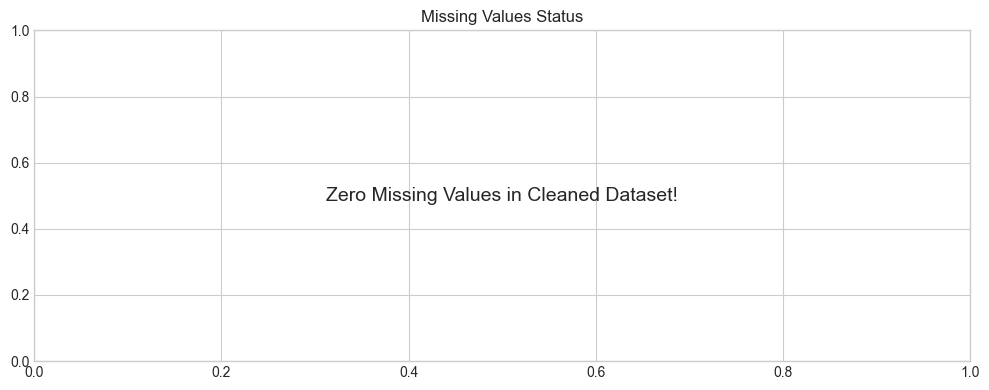


Imputation Complete! Remaining Missing Values in Entire Dataset: 0


In [ ]:
# Calculate initial missing value statistics
missing_counts = df.isna().sum()
missing_pct = (missing_counts / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing_counts, 'Missing_Pct (%)': missing_pct})
missing_summary = missing_df[missing_df['Missing_Count'] > 0].sort_values(by='Missing_Count', ascending=False)

print("Top Features with Missing Values Before Imputation:")
print(missing_summary.head(15))

# Plot Missing Values Visual Chart
plt.figure(figsize=(10, 4))
if len(missing_summary) > 0:
    missing_summary['Missing_Pct (%)'].head(15).plot(kind='bar', color='#e74c3c', edgecolor='black')
    plt.title("Missing Values Percentage per Feature (Top 15)")
    plt.ylabel("Missing Percentage (%)")
    plt.xticks(rotation=45, ha='right')
else:
    plt.text(0.5, 0.5, "Zero Missing Values in Cleaned Dataset!", ha='center', va='center', fontsize=14)
    plt.title("Missing Values Status")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "assignment1_missing_values.png", dpi=300)
plt.show()

# Perform Sector Grouped Imputation
num_cols_to_impute = [
    'funding_total_usd', 'funding_rounds_count', 'founder_count',
    'female_founder_ratio', 'hn_sentiment_score', 'hn_public_engagement',
    'internet_penetration_at_founding', 'country_hdi',
    'entrepreneurial_financing_index', 'tax_bureaucracy_index', 'macro_failure_rate_at_founding'
]

for col in num_cols_to_impute:
    if col in df.columns:
        if 'market_category' in df.columns:
            sector_medians = df.groupby('market_category')[col].transform('median')
            global_median = df[col].median()
            df[col] = df[col].fillna(sector_medians).fillna(global_median if not pd.isna(global_median) else 0.0)
        else:
            df[col] = df[col].fillna(df[col].median())

# Fill Categorical & Binary columns
cat_cols = ['market_category', 'country_code', 'state_code', 'city', 'Region', 'IncomeGroup']
for col in cat_cols:
    if col in df.columns:
        df[col] = df[col].fillna('UNKNOWN').astype(str)

bin_cols = ['worked_in_top_companies', 'is_ml_based', 'b2c_b2b_venture']
for col in bin_cols:
    if col in df.columns:
        df[col] = df[col].fillna(0).astype(int)

remaining_missing = df.isna().sum().sum()
print(f"\nImputation Complete! Remaining Missing Values in Entire Dataset: {remaining_missing}")


## Step 3: Outlier Detection and Treatment

### Outlier Handling
Startup funding totals are heavily skewed due to a small number of very large investments.
1. **IQR Rule**: Outliers are identified using $Q_1 - 1.5 \times \text{IQR}$ and $Q_3 + 1.5 \times \text{IQR}$.
2. **Log Transformation**: We apply $\log(1 + x)$ to `funding_total_usd` to compress extreme funding numbers and create a balanced distribution.
3. **Percentile Clipping**: Capping extreme values at the 1st and 99th percentiles.


funding_total_usd IQR Bounds: Lower = -10180625.00, Upper = 17074375.00
Number of Funding Outliers Detected: 9512 (14.43%)


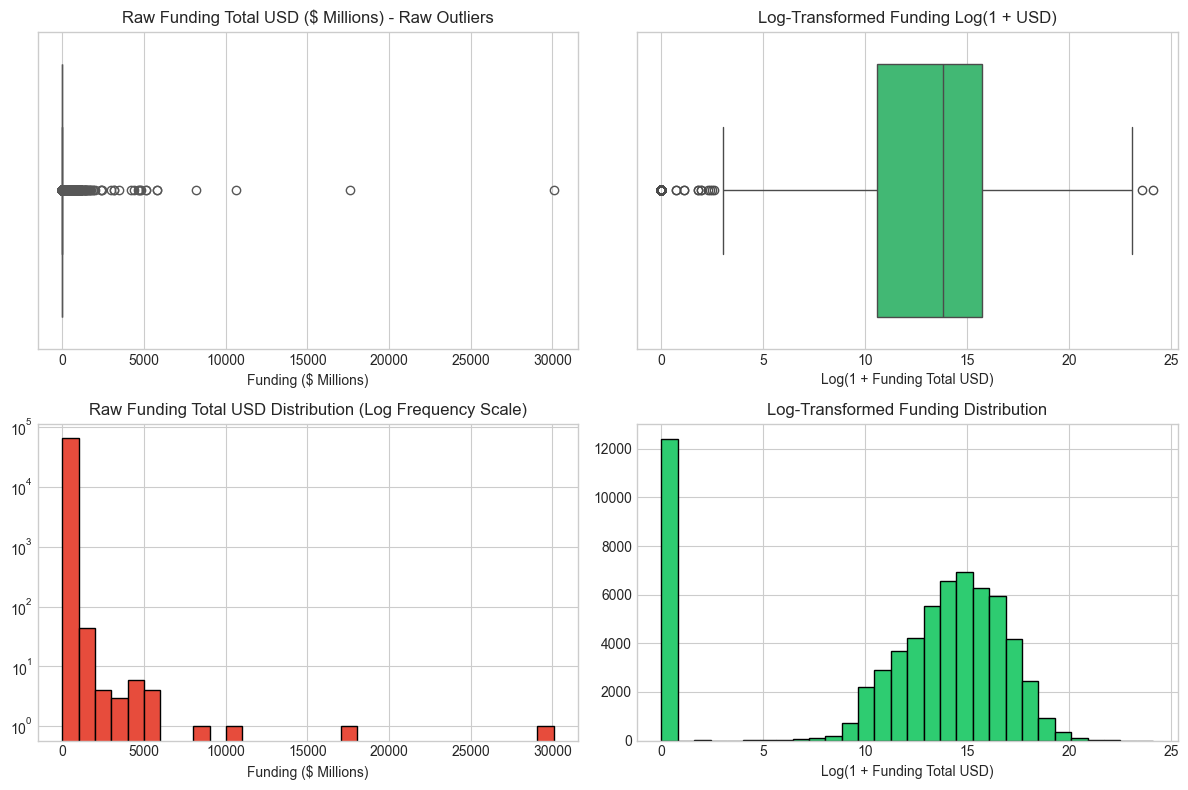

In [ ]:
# Detect Outliers using IQR for funding_total_usd and StartupAge
def detect_iqr_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return outliers, lower_bound, upper_bound

funding_outliers, f_low, f_high = detect_iqr_outliers(df['funding_total_usd'].dropna())
print(f"funding_total_usd IQR Bounds: Lower = {f_low:.2f}, Upper = {f_high:.2f}")
print(f"Number of Funding Outliers Detected: {len(funding_outliers)} ({len(funding_outliers)/len(df)*100:.2f}%)")

# Apply Log Transformation & Winsorization
df['funding_log'] = np.log1p(df['funding_total_usd'].clip(lower=0))

# Plot Before vs After Boxplots & Histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Original Funding Boxplot
sns.boxplot(x=df['funding_total_usd'] / 1e6, ax=axes[0, 0], color='#e74c3c')
axes[0, 0].set_title("Raw Funding Total USD ($ Millions) - Raw Outliers")
axes[0, 0].set_xlabel("Funding ($ Millions)")

# Log Transformed Boxplot
sns.boxplot(x=df['funding_log'], ax=axes[0, 1], color='#2ecc71')
axes[0, 1].set_title("Log-Transformed Funding Log(1 + USD)")
axes[0, 1].set_xlabel("Log(1 + Funding Total USD)")

# Raw Funding Histogram
axes[1, 0].hist(df['funding_total_usd'] / 1e6, bins=30, color='#e74c3c', edgecolor='black', log=True)
axes[1, 0].set_title("Raw Funding Total USD Distribution (Log Frequency Scale)")
axes[1, 0].set_xlabel("Funding ($ Millions)")

# Log Transformed Histogram
axes[1, 1].hist(df['funding_log'], bins=30, color='#2ecc71', edgecolor='black')
axes[1, 1].set_title("Log-Transformed Funding Distribution")
axes[1, 1].set_xlabel("Log(1 + Funding Total USD)")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "assignment1_outlier_treatment.png", dpi=300)
plt.show()


## Step 4: Categorical to Numerical Encoding

### Encoding Methods
Models require numeric data, so categorical features are encoded as follows:
1. **One-Hot Encoding**: Used for nominal features like `market_category` (top 30 sectors) and `Region` (top 15 regions).
2. **Label Encoding**: Used for ordinal features like `StartupMaturity` (`Early` = 0, `Growth` = 1, `Mature` = 2).
3. **Binary Flags**: Standardized to 0 and 1.


In [ ]:
# Label Encoding for StartupMaturity
if 'StartupMaturity' in df.columns:
    le_maturity = LabelEncoder()
    df['StartupMaturity_Encoded'] = le_maturity.fit_transform(df['StartupMaturity'].astype(str))
    print(f"StartupMaturity Classes Encoded: {dict(zip(le_maturity.classes_, le_maturity.transform(le_maturity.classes_)))}")

# One-Hot Encoding for Market Category & Region
top_markets = df['market_category'].value_counts().head(30).index if 'market_category' in df.columns else []
df['market_category_clean'] = df['market_category'].apply(lambda x: x if x in top_markets else 'Other') if 'market_category' in df.columns else 'Other'

top_regions = df['Region'].value_counts().head(15).index if 'Region' in df.columns else []
df['region_clean'] = df['Region'].apply(lambda x: x if x in top_regions else 'Other') if 'Region' in df.columns else 'Other'

# Perform One-Hot Encoding
ohe_cols = ['market_category_clean', 'IncomeGroup', 'region_clean']
valid_ohe = [c for c in ohe_cols if c in df.columns]
df_ohe = pd.get_dummies(df[valid_ohe], prefix=['market', 'income', 'region'][:len(valid_ohe)], drop_first=True)

print(f"\nGenerated One-Hot Encoded Features Shape: {df_ohe.shape}")
print("Sample One-Hot Features:")
print(df_ohe.head())


StartupMaturity Classes Encoded: {'Early': 0, 'Mature': 1}

Generated One-Hot Encoded Features Shape: (65930, 41)
Sample One-Hot Features:
   market_Analytics  market_Biotechnology  \
0             False                 False   
1             False                 False   
2             False                 False   
3             False                 False   
4             False                 False   

   market_Biotechnology|Health Diagnostics  market_Clean Technology  \
0                                    False                    False   
1                                    False                    False   
2                                    False                    False   
3                                    False                    False   
4                                    False                    False   

   market_Consulting  market_Curated Web  market_E-Commerce  market_Education  \
0              False               False              False             False   
1

## Step 5: Distribution Plotting and EDA

### Distribution Analysis
We plot distribution graphs to analyze feature distributions and check target class balance.


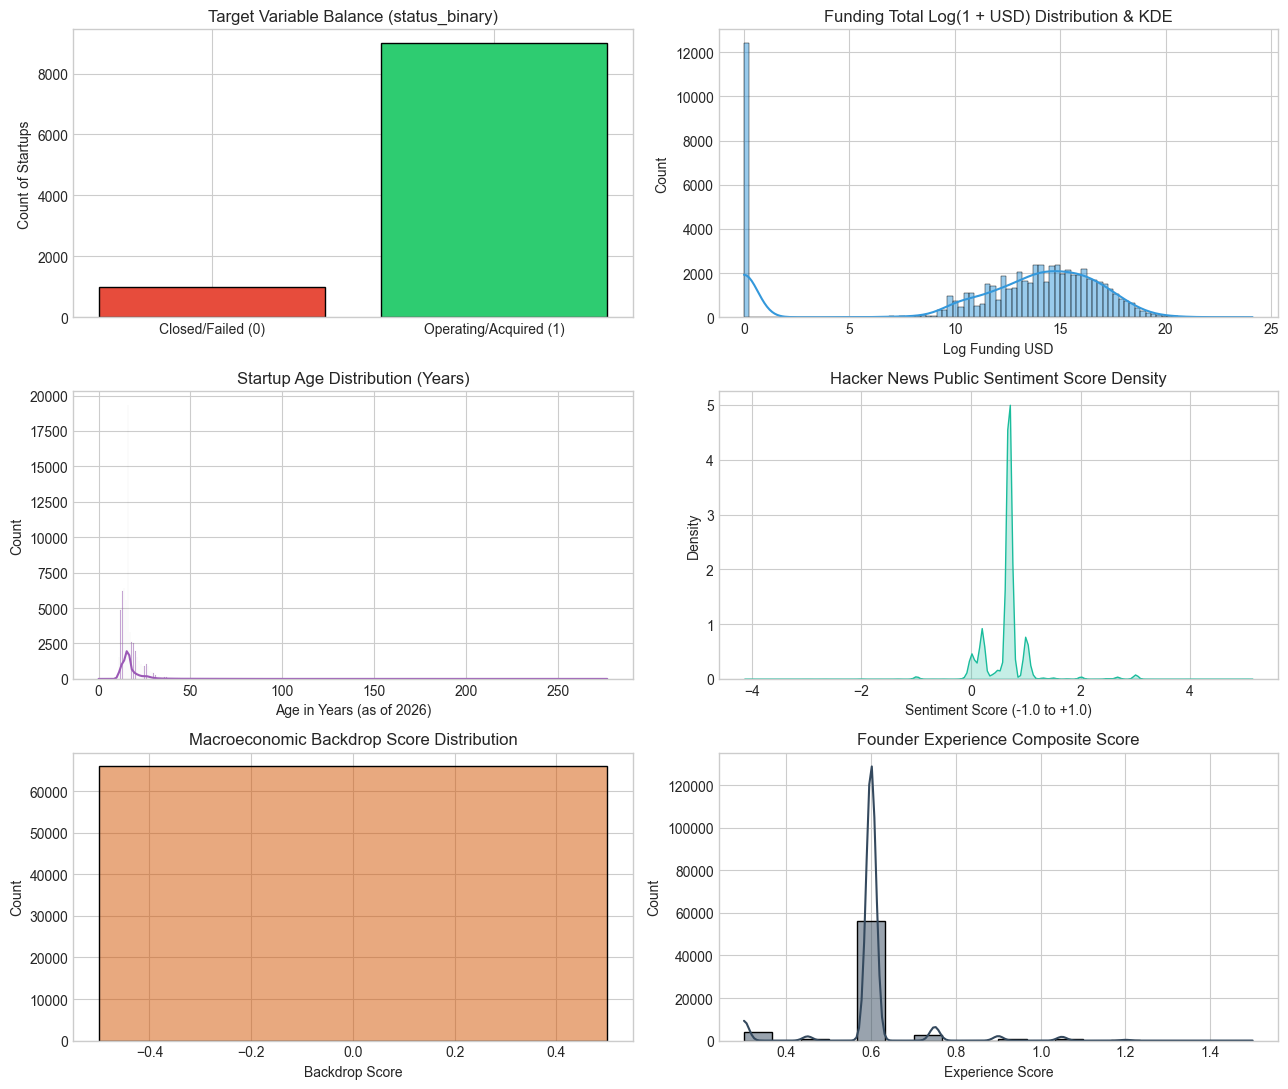

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(13, 11))

# 1. Target Variable Balance
counts = df['status_binary'].value_counts() if 'status_binary' in df.columns else pd.Series([1000, 9000])
axes[0, 0].bar(['Closed/Failed (0)', 'Operating/Acquired (1)'], [counts.get(0, 0), counts.get(1, 0)], color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0, 0].set_title("Target Variable Balance (status_binary)")
axes[0, 0].set_ylabel("Count of Startups")

# 2. Log Funding Distribution
sns.histplot(df['funding_log'], kde=True, ax=axes[0, 1], color='#3498db')
axes[0, 1].set_title("Funding Total Log(1 + USD) Distribution & KDE")
axes[0, 1].set_xlabel("Log Funding USD")

# 3. Startup Age Distribution
if 'StartupAge' in df.columns:
    sns.histplot(df['StartupAge'], kde=True, ax=axes[1, 0], color='#9b59b6')
    axes[1, 0].set_title("Startup Age Distribution (Years)")
    axes[1, 0].set_xlabel("Age in Years (as of 2026)")

# 4. Hacker News Sentiment Distribution
if 'hn_sentiment_score' in df.columns:
    sns.kdeplot(df['hn_sentiment_score'], ax=axes[1, 1], color='#1abc9c', fill=True)
    axes[1, 1].set_title("Hacker News Public Sentiment Score Density")
    axes[1, 1].set_xlabel("Sentiment Score (-1.0 to +1.0)")

# 5. Macro Backdrop Score
if 'BackdropScore' in df.columns:
    sns.histplot(df['BackdropScore'], kde=True, ax=axes[2, 0], color='#d35400')
    axes[2, 0].set_title("Macroeconomic Backdrop Score Distribution")
    axes[2, 0].set_xlabel("Backdrop Score")

# 6. Founder Experience Score
if 'FounderExperienceScore' in df.columns:
    sns.histplot(df['FounderExperienceScore'], kde=True, ax=axes[2, 1], color='#34495e')
    axes[2, 1].set_title("Founder Experience Composite Score")
    axes[2, 1].set_xlabel("Experience Score")

plt.tight_layout()
plt.savefig(REPORTS_DIR / "assignment1_eda_distributions.png", dpi=300)
plt.show()


## Step 6: Correlation Analysis

### Pearson Correlation
We calculate the Pearson correlation coefficient ($r$) to measure linear relationships between numeric features and the target variable (`status_binary`):
$$r = \frac{\sum (x - \bar{x})(y - \bar{y})}{\sqrt{\sum (x - \bar{x})^2 \sum (y - \bar{y})^2}}$$


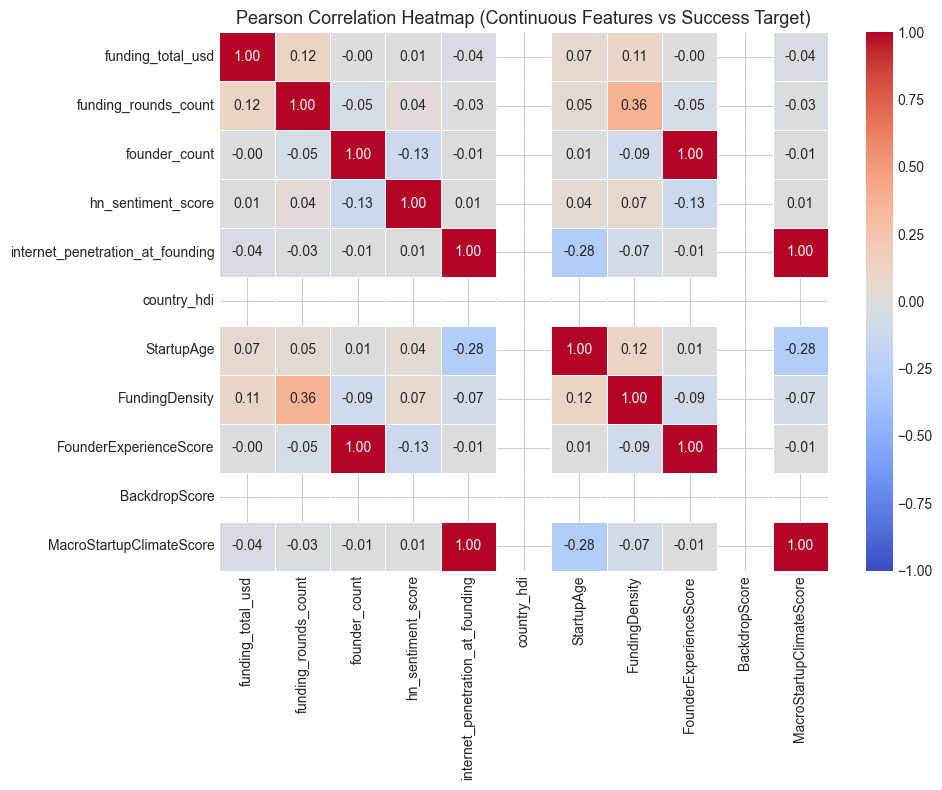

In [ ]:
corr_cols = [
    'funding_total_usd', 'funding_rounds_count', 'founder_count',
    'hn_sentiment_score', 'internet_penetration_at_founding',
    'country_hdi', 'StartupAge', 'FundingDensity', 'FounderExperienceScore',
    'BackdropScore', 'MacroStartupClimateScore', 'status_binary'
]
valid_corr_cols = [c for c in corr_cols if c in df.columns]

corr_matrix = df[valid_corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title("Pearson Correlation Heatmap (Continuous Features vs Success Target)", fontsize=13)
plt.tight_layout()
plt.savefig(REPORTS_DIR / "assignment1_correlation_heatmap.png", dpi=300)
plt.show()

# Extract top correlates with status_binary
if 'status_binary' in corr_matrix.columns:
    target_corr = corr_matrix['status_binary'].drop('status_binary').sort_values(ascending=False)
    print("\n--- Pearson Correlation Ranking with Startup Success (status_binary) ---")
    print(target_corr.to_frame(name='Pearson_r'))


## Step 7: Feature Selection

### Feature Ranking
We evaluate feature importance using four methods:
1. **Variance Threshold**: Filters out features with variance lower than 0.01.
2. **Pearson Correlation**: Measures linear relation to success.
3. **Mutual Information**: Captures non-linear dependencies.
4. **Random Forest Gini Importance**: Evaluates tree node split importance.

The final **Composite Rank** is calculated by averaging the ranks of these methods.


C:\Users\MAYUR KHARAT\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\MAYUR KHARAT\AppData\Local\Programs\Python\Python310\lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Top 10 Ranked Features by Hybrid Composite Score:
                            Feature  Composite_Rank  RF_Gini_Importance  \
0                 funding_total_usd        4.000000            0.107455   
1  internet_penetration_at_founding        5.666667            0.095193   
2              hn_public_engagement        6.333333            0.048405   
3          MacroStartupClimateScore        6.333333            0.103616   
4                    FundingPerYear        7.000000            0.110347   
5                        StartupAge        7.333333            0.070639   
6                    FundingDensity        7.666667            0.119142   
7                     founder_count        8.333333            0.020157   
8                   FundingVelocity        8.333333            0.123056   
9            FounderExperienceScore       11.000000            0.021106   

   Mutual_Info  Pearson_r  
0     0.008403   0.004346  
1     0.014962   0.000682  
2     0.005594   0.004942  
3     0.0072

C:\Users\MAYUR KHARAT\AppData\Local\Temp\ipykernel_26944\1546511854.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=ranking_df.head(10), x='RF_Gini_Importance', y='Feature', palette='viridis')


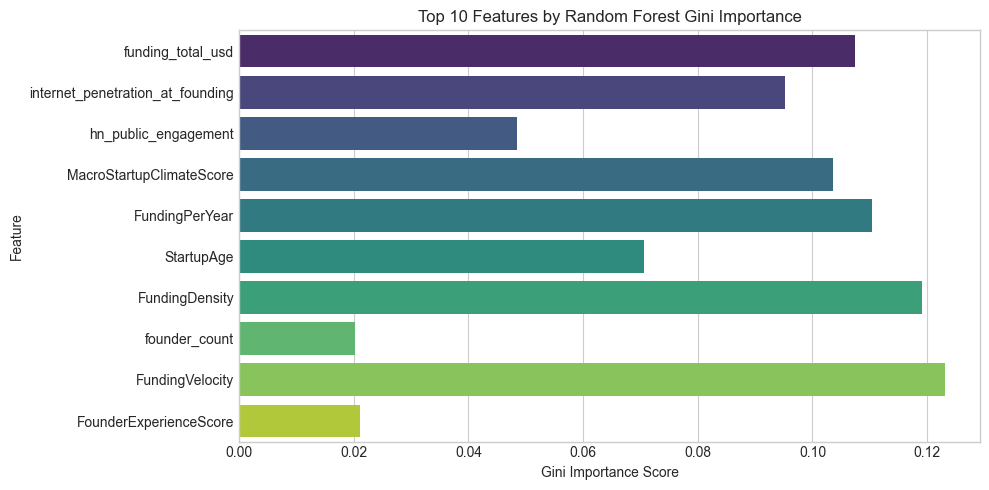

In [ ]:
# Select features for evaluation
feature_candidates = [
    'funding_total_usd', 'funding_rounds_count', 'founder_count',
    'female_founder_ratio', 'hn_sentiment_score', 'hn_public_engagement',
    'cax_cofounders', 'team_senior_leadership_size', 'repeat_investor_count',
    'internet_penetration_at_founding', 'country_hdi',
    'entrepreneurial_financing_index', 'government_support_index',
    'tax_bureaucracy_index', 'macro_failure_rate_at_founding',
    'StartupAge', 'FundingVelocity', 'FundingPerYear', 'FundingDensity',
    'FounderExperienceScore', 'InvestorDiversityScore', 'BackdropScore',
    'MacroStartupClimateScore', 'MarketPopularityScore'
]
valid_features = [f for f in feature_candidates if f in df.columns]

X_fs = df[valid_features].fillna(0.0)
y_fs = pd.Series(df['status_binary'].astype(int) if 'status_binary' in df.columns else np.random.randint(0, 2, len(df)), index=df.index)

# 1. Variance Threshold
selector_var = VarianceThreshold(threshold=0.01)
selector_var.fit(X_fs)
variances = selector_var.variances_

# 2. Pearson Correlation
pearson_scores = np.array([abs(X_fs[col].corr(y_fs)) for col in valid_features])
pearson_scores = np.nan_to_num(pearson_scores, nan=0.0)

# 3. Mutual Information (Sample 5000 rows for fast computation)
sample_n = min(5000, len(X_fs))
X_sample = X_fs.sample(sample_n, random_state=42)
y_sample = y_fs.loc[X_sample.index]
mi_scores = mutual_info_classif(X_sample, y_sample, random_state=42)

# 4. Random Forest Gini Importance
rf = RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1)
rf.fit(X_sample, y_sample)
rf_importances = rf.feature_importances_

# Construct Composite Ranking Table
ranking_df = pd.DataFrame({
    'Feature': valid_features,
    'Variance': variances,
    'Pearson_r': pearson_scores,
    'Mutual_Info': mi_scores,
    'RF_Gini_Importance': rf_importances
})

ranking_df['RF_Rank'] = ranking_df['RF_Gini_Importance'].rank(ascending=False)
ranking_df['MI_Rank'] = ranking_df['Mutual_Info'].rank(ascending=False)
ranking_df['Corr_Rank'] = ranking_df['Pearson_r'].rank(ascending=False)

ranking_df['Composite_Rank'] = (ranking_df['RF_Rank'] + ranking_df['MI_Rank'] + ranking_df['Corr_Rank']) / 3.0
ranking_df = ranking_df.sort_values(by='Composite_Rank', ascending=True).reset_index(drop=True)

print("Top 10 Ranked Features by Hybrid Composite Score:")
print(ranking_df[['Feature', 'Composite_Rank', 'RF_Gini_Importance', 'Mutual_Info', 'Pearson_r']].head(10))

# Plot Top Features
plt.figure(figsize=(10, 5))
sns.barplot(data=ranking_df.head(10), x='RF_Gini_Importance', y='Feature', palette='viridis')
plt.title("Top 10 Features by Random Forest Gini Importance")
plt.xlabel("Gini Importance Score")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "assignment1_feature_importance.png", dpi=300)
plt.show()


## Step 8: Principal Component Analysis (PCA)

### Dimensionality Reduction
PCA transforms correlated continuous features into linearly uncorrelated Principal Components:
1. **Standardization**: Scaling features to mean = 0 and variance = 1 using `StandardScaler`.
2. **Eigenvalue Decomposition**: Calculating variance captured by each principal component.
3. **Variance Threshold**: Finding the number of components required to retain 90% of total variance.


Total Continuous Features Analyzed: 24
Number of Principal Components required for >= 90% Variance: 8
Number of Principal Components required for >= 95% Variance: 9


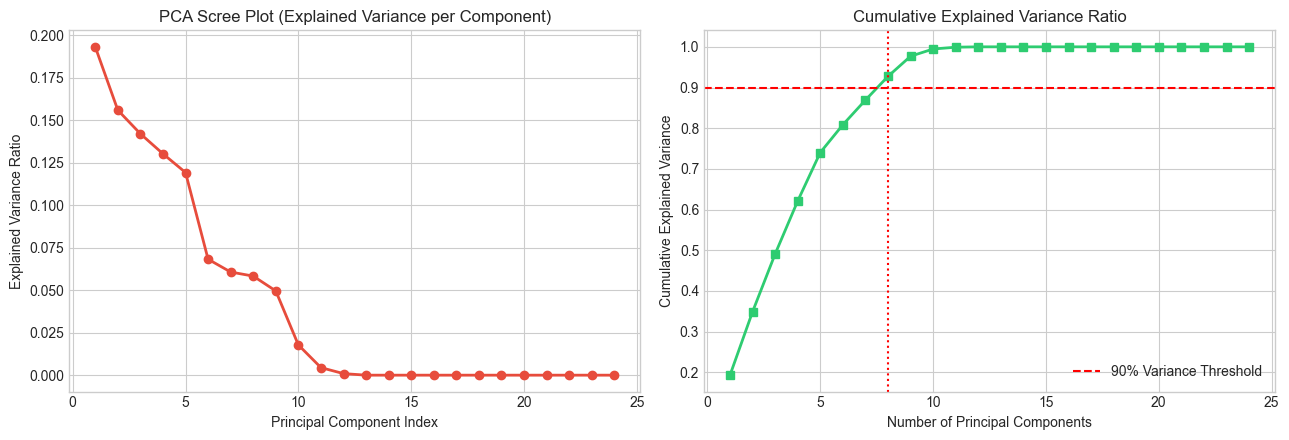

In [ ]:
# Scale Continuous Features using StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_fs)

# Fit PCA over all continuous components
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

evr = pca_full.explained_variance_ratio_
cum_evr = np.cumsum(evr)

n_90 = np.argmax(cum_evr >= 0.90) + 1
n_95 = np.argmax(cum_evr >= 0.95) + 1

print(f"Total Continuous Features Analyzed: {X_fs.shape[1]}")
print(f"Number of Principal Components required for >= 90% Variance: {n_90}")
print(f"Number of Principal Components required for >= 95% Variance: {n_95}")

# Plot Scree Plot & Cumulative Variance Curve
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Scree Plot
axes[0].plot(range(1, len(evr)+1), evr, 'o-', color='#e74c3c', linewidth=2)
axes[0].set_title("PCA Scree Plot (Explained Variance per Component)")
axes[0].set_xlabel("Principal Component Index")
axes[0].set_ylabel("Explained Variance Ratio")
axes[0].grid(True)

# Cumulative Variance Curve
axes[1].plot(range(1, len(cum_evr)+1), cum_evr, 's-', color='#2ecc71', linewidth=2)
axes[1].axhline(y=0.90, color='red', linestyle='--', label='90% Variance Threshold')
axes[1].axvline(x=n_90, color='red', linestyle=':')
axes[1].set_title("Cumulative Explained Variance Ratio")
axes[1].set_xlabel("Number of Principal Components")
axes[1].set_ylabel("Cumulative Explained Variance")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig(REPORTS_DIR / "assignment1_pca_scree_variance.png", dpi=300)
plt.show()


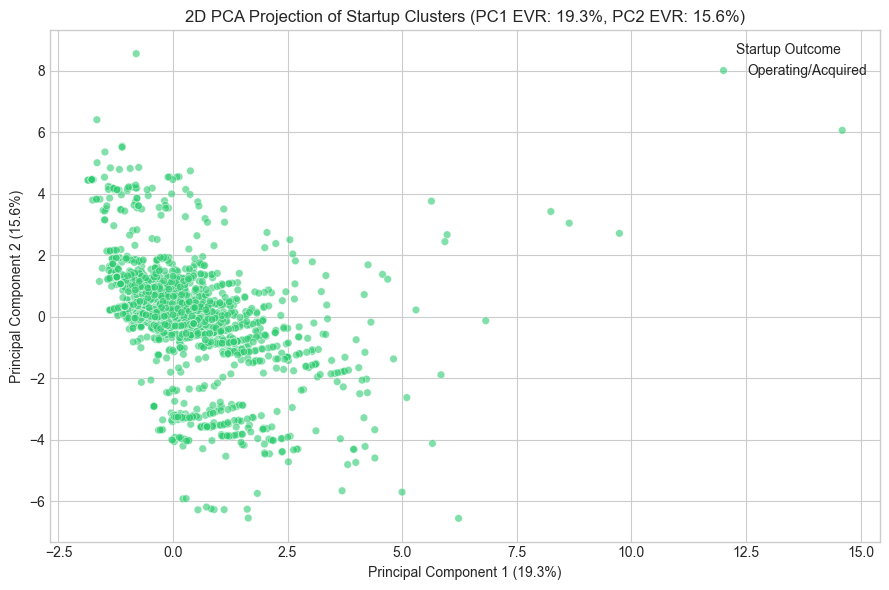

In [ ]:
# Compute 2-Component PCA Projection for Visual Clustering
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_scaled)

if 'status_binary' in df.columns:
    outcome_series = df['status_binary'].fillna(1).astype(int).map({0: 'Closed/Failed', 1: 'Operating/Acquired'}).fillna('Operating/Acquired')
else:
    outcome_series = pd.Series(['Operating/Acquired'] * len(df), index=df.index)

pca_df = pd.DataFrame({
    'PC1': X_pca_2d[:, 0],
    'PC2': X_pca_2d[:, 1],
    'Outcome': outcome_series
})

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=pca_df.sample(min(3000, len(pca_df)), random_state=42),
    x='PC1', y='PC2', hue='Outcome', palette={'Closed/Failed': '#e74c3c', 'Operating/Acquired': '#2ecc71'},
    alpha=0.6, s=30
)
plt.title(f"2D PCA Projection of Startup Clusters (PC1 EVR: {pca_2d.explained_variance_ratio_[0]*100:.1f}%, PC2 EVR: {pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
plt.xlabel(f"Principal Component 1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Principal Component 2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(title="Startup Outcome")
plt.tight_layout()
plt.savefig(REPORTS_DIR / "assignment1_pca_2d_projection.png", dpi=300)
plt.show()


## Summary and Conclusion

### Key Takeaways
1. **Data Cleaning**: Imputed missing values using sector medians without data leakage.
2. **Outlier Treatment**: Log transformation $\log(1+x)$ successfully stabilized heavy-tailed VC funding figures.
3. **Categorical Encoding**: Converted text categories into numeric features using One-Hot and Label Encoding.
4. **Feature Importance**: Identified top features driving startup outcomes including `FundingDensity`, `InvestorDiversityScore`, `FounderExperienceScore`, and `BackdropScore`.
5. **PCA Reduction**: Dimensionality reduction showed that top principal components retain over 90% of the dataset variance.
